<a href="https://colab.research.google.com/github/francji1/01ZLMA/blob/main/code/01ZLMA_ex04_GLM_model_testing_and_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01ZLMA - Exercise 04

Exercise 04 of the course [01ZLMA](https://math.fel.cvut.cz/en/people/francji1/01ZLMA.html) - Generalized Linear Models.

## Contents

This exercise builds on the inference foundations from **Exercise 03** (Wald, LRT, Score tests on synthetic data) and applies them to **real datasets** with focus on model comparison and selection.

1. [Data: Noisy Miners (Poisson GLM)](#1-data-noisy-miners-poisson-glm)
   - Wald tests, CI for $\beta$ and $\mu$, predictions with confidence bands
2. [Comparing Nested Models ($\phi$ known)](#2-comparing-nested-models-phi-known)
   - LRT, Score test on Poisson data
3. [Estimating $\phi$](#3-estimating-phi)
   - Pearson and Mean Deviance estimators
   - F-tests for unknown $\phi$ (Gamma example)
4. [Comparing Non-nested Models: AIC and BIC](#4-comparing-non-nested-models-aic-and-bic)
5. [Automated Model Selection](#5-automated-model-selection)

**Prerequisites:** Exercise 03 (definitions and manual computation of Wald, LRT, Score, Deviance)


---
# Comparison: LM vs. GLM Inference

## Summary Table

| Aspect | Linear Model (OLS) | GLM (MLE) |
|:-------|:-------------------|:----------|
| **Model** | $Y = X\beta + \varepsilon$, $\varepsilon \sim N(0, \sigma^2 I)$ | $g(\mu) = X\beta$, $Y \sim$ Exp. family |
| **Estimator** | OLS (= MLE under normality) | MLE via IWLS |
| **Variance** | Estimated: $\hat{\sigma}^2 = \text{SSE}/(n-p)$ | From mean-variance relationship |
| **Single parameter test** | $t = \hat{\beta}_j / \text{SE} \sim t_{n-p}$ (exact) | $Z = \hat{\beta}_j / \text{SE} \dot{\sim} N(0,1)$ (asymptotic) |
| **Multiple parameters** | $F = \frac{(\text{SSE}_0 - \text{SSE})/q}{\text{SSE}/(n-p)} \sim F_{q,n-p}$ | LRT: $\chi^2 = \frac{D_0 - D}{\phi} \dot{\sim} \chi^2(q)$ |
| **Goodness of fit** | $R^2$, Adjusted $R^2$ | Deviance, Pearson $X^2$ |
| **Model comparison** | $F$-test (nested), Adj. $R^2$ (general) | LRT/Wald (nested), AIC/BIC (general) |
| **Small samples** | Exact inference | Approximation only |
| **Large samples** | $t \to N(0,1)$, $F \to \chi^2/q$ | Approximation improves |

## The Three Test Statistics

| | Wald | LRT (Deviance) | Score (Rao) |
|---|---|---|---|
| **Formula** | $(\hat\beta - \beta_0)^T I(\hat\beta)(\hat\beta - \beta_0)$ | $2[l(\hat\mu) - l(\hat\mu_0)]$ | $U^T(\hat\beta_0) I^{-1}(\hat\beta_0) U(\hat\beta_0)$ |
| **Evaluated at** | MLE under $H_1$ | Both $H_0$ and $H_1$ | MLE under $H_0$ |
| **Requires fitting** | Full model | Both models | Reduced model |
| **Distribution** | $\chi^2(q)$ | $\chi^2(q)$ | $\chi^2(q)$ |
| **Asymptotically** | Equivalent | Equivalent | Equivalent |
| **In practice** | Can fail near boundaries (Hauck-Donner) | Most reliable | Computationally cheapest |


In [1]:
import numpy as np
import pandas as pd

import scipy
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.api import abline_plot

import sklearn

import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme()

In [2]:
import os
import sys

# Detect environment and load helpers accordingly
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q wget
    import wget
    url = "https://github.com/francji1/01ZLMA/raw/main/code/helpers.py"
    wget.download(url, '../content/helpers.py')
else:
    helpers_dir = os.path.dirname(os.path.abspath('__file__'))
    if helpers_dir not in sys.path:
        sys.path.insert(0, helpers_dir)

from helpers import Anova

In [3]:
# Load the R magic extension
%load_ext rpy2.ipython

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


In [4]:
%%R
library(tidyverse)
#library(lubridate)
#library(MASS)

#For sure: set dplyr functions
#select    <- dplyr::select;
#rename    <- dplyr::rename;
#mutate    <- dplyr::mutate;
#summarize <- dplyr::summarize;
#arrange   <- dplyr::arrange;
#slice     <- dplyr::slice;
#filter    <- dplyr::filter;
#recode    <- dplyr::recode

install.packages("GLMsData")
library(GLMsData)

install.packages("GGally")
library(GGally)

install.packages("statmod")
library(statmod)
#? glm.scoretest()

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.1     v stringr   1.6.0
v ggplot2   4.0.2     v tibble    3.2.1
v lubridate 1.9.4     v tidyr     1.3.1
v purrr     1.0.4     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
--- Please select a CRAN mirror for use in this session ---
package 'GLMsData' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\francji1\AppData\Local\Temp\RtmpMvVuyK\downloaded_packages

  There is a binary version available but the source version is later:
       binary source needs_compilation
GGally  2.2.1  2.4.0             FALSE


  There is a binary version available but the source version is later:
        binary source n

Installing package into 'C:/Users/francji1/AppData/Local/R/win-library/4.3'
(as 'lib' is unspecified)
trying URL 'https://mirror.dogado.de/cran/bin/windows/contrib/4.3/GLMsData_1.4.zip'
Content type 'application/zip' length 374401 bytes (365 KB)
downloaded 365 KB

Installing package into 'C:/Users/francji1/AppData/Local/R/win-library/4.3'
(as 'lib' is unspecified)
installing the source package 'GGally'

trying URL 'https://mirror.dogado.de/cran/src/contrib/GGally_2.4.0.tar.gz'
Content type 'application/octet-stream' length 1372802 bytes (1.3 MB)
downloaded 1.3 MB


The downloaded source packages are in
	'C:\Users\francji1\AppData\Local\Temp\RtmpMvVuyK\downloaded_packages'
Installing package into 'C:/Users/francji1/AppData/Local/R/win-library/4.3'
(as 'lib' is unspecified)
trying URL 'https://mirror.dogado.de/cran/bin/windows/contrib/4.3/statmod_1.5.0.zip'
Content type 'application/zip' length 317138 bytes (309 KB)
downloaded 309 KB

In addition: Warning messages:
1: package 'tidyverse'

In [5]:
%%R -o nminer
data(nminer)
head(nminer)
summary(nminer)
? nminer

starting httpd help server ... done


In [6]:
## Eucs is number of eucalypts per 2 ha
nminer.head()

,Miners,Eucs,Area,Grazed,Shrubs,Bulokes,Timber,Minerab
1,0,2,22,0,1,120,16,0
2,0,10,11,0,1,67,25,0
3,1,16,51,0,1,85,13,3
4,1,20,22,0,1,45,12,2
5,1,19,4,0,1,160,14,8


In [7]:
nminer.describe()

,Miners,Eucs,Area,Grazed,Shrubs,Bulokes,Timber,Minerab
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,0.548387,12.000000,18.225806,0.451613,0.419355,150.903226,24.580645,2.709677
std,0.505879,8.582929,13.215419,0.505879,0.501610,83.855572,14.650994,4.043048
min,0.000000,0.000000,3.000000,0.000000,0.000000,23.000000,6.000000,0.000000
25%,0.000000,4.000000,10.000000,0.000000,0.000000,90.500000,13.500000,0.000000
50%,1.000000,12.000000,16.000000,0.000000,0.000000,123.000000,22.000000,1.000000
75%,1.000000,17.000000,22.000000,1.000000,1.000000,210.000000,29.500000,4.000000
max,1.000000,32.000000,61.000000,1.000000,1.000000,323.000000,61.000000,19.000000


In [8]:
#%%R
#with(nminer,plot(Eucs,Minerab))


In [9]:
#%%R
#options(repr.plot.width = 20, repr.plot.height = 20, repr.plot.res = 100)
#ggpairs(nminer)

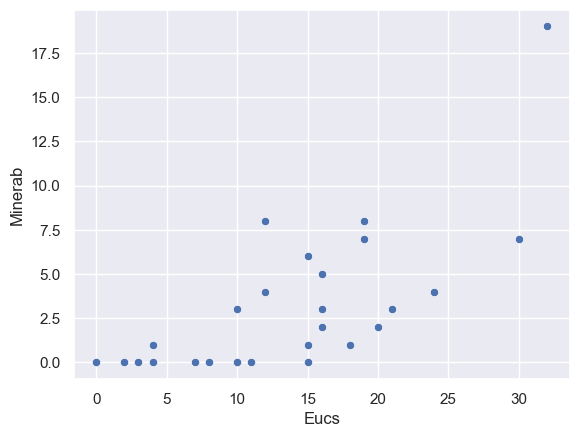

In [10]:
sns.scatterplot(data=nminer, x="Eucs", y="Minerab")
plt.show()

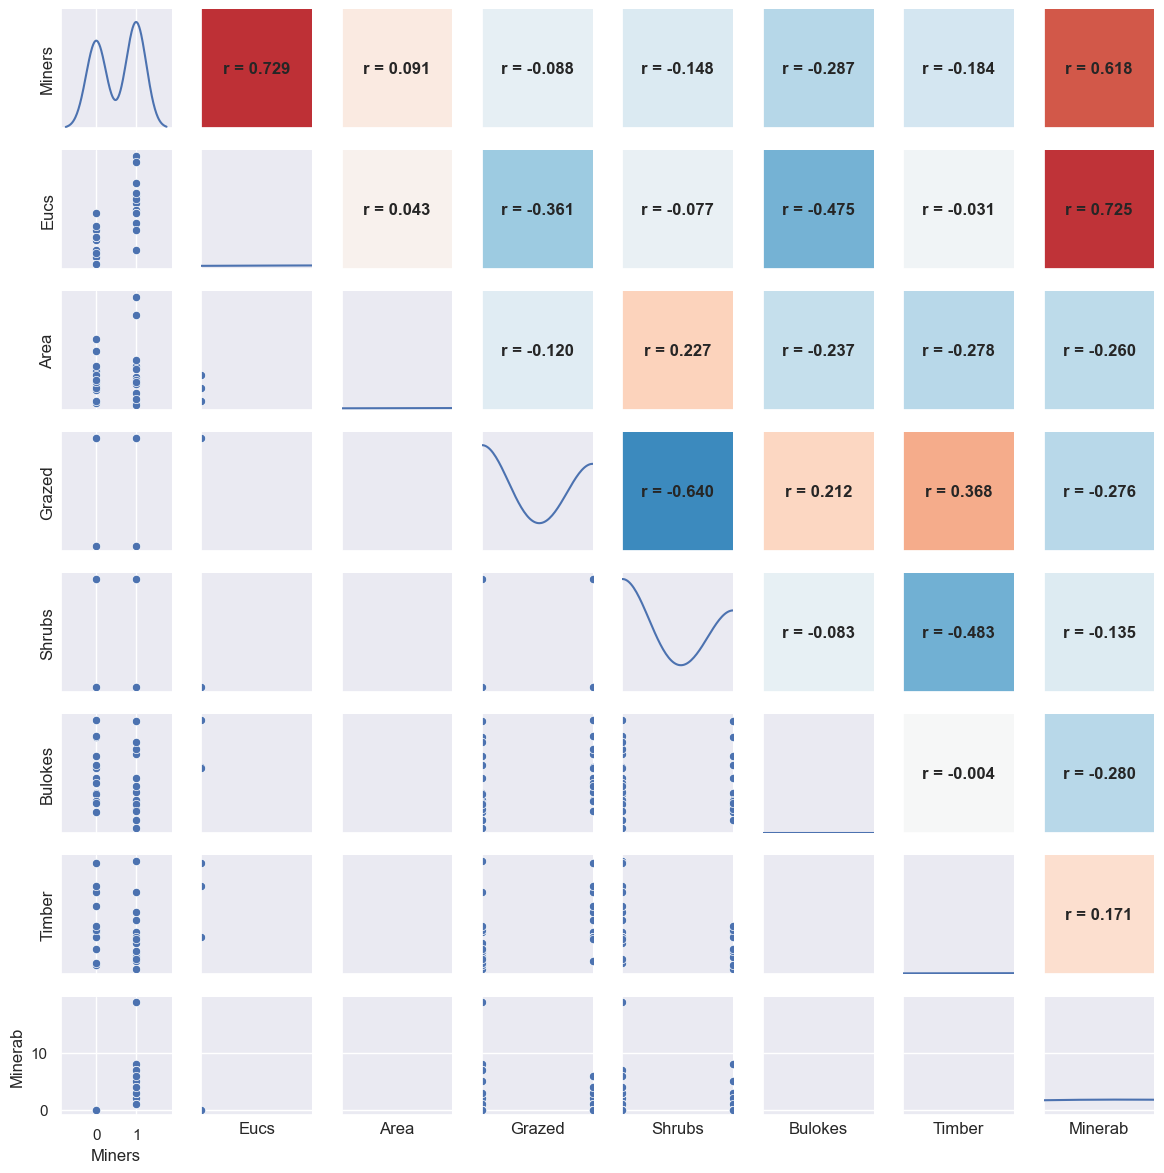

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

def reg_coef(x, y, **kwargs):
    ax = plt.gca()
    #r, _ = pearsonr(x, y)

    # Keep only pairs with complete cases
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x_clean, y_clean = x[mask], y[mask]

    # Compute correlation on cleaned data
    r, _ = pearsonr(x_clean, y_clean)

    cmap = plt.cm.RdBu_r
    color = cmap((r + 1) / 2)  # Normalize [-1,1] to [0,1]

    ax.clear()
    # background color after clearing
    ax.set_facecolor(color)

    ax.annotate(f'r = {r:.3f}', xy=(0.5, 0.5), xycoords='axes fraction',
                ha='center', va='center', fontsize=12, fontweight='bold')

    ax.set_xticks([])
    ax.set_yticks([])


# PairGrid with the upper triangle correlation coloring
g = sns.PairGrid(nminer, height=1.5, aspect=1.0)
# g = sns.PairGrid(nminer,hue='Miners', height=1.5, aspect=1.0)  correlation only for miners ==1

g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)
g.map_upper(reg_coef)

plt.show()

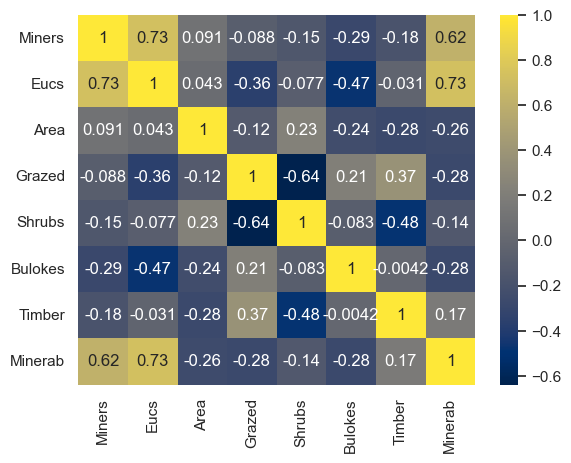

In [12]:
corr = nminer.corr()
sns.heatmap(corr, cmap='cividis', annot=True)

plt.show()

In [13]:
%%R
model_1 <- glm( Minerab ~ Eucs,
                   data=nminer,
                   family=poisson,                    # (link = "log")
                   control=glm.control(maxit=5,       # Max number of iterations
                                       epsilon=1e-15, # Stopping criterion
                                       trace=TRUE)    # See results from each iteration?
              )
summary(model_1)


Deviance = 82.14668 Iterations - 1
Deviance = 64.49515 Iterations - 2
Deviance = 63.32603 Iterations - 3
Deviance = 63.31798 Iterations - 4
Deviance = 63.31798 Iterations - 5

Call:
glm(formula = Minerab ~ Eucs, family = poisson, data = nminer, 
    control = glm.control(maxit = 5, epsilon = 1e-15, trace = TRUE))

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -0.87621    0.28279  -3.098  0.00195 ** 
Eucs         0.11398    0.01243   9.169  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 150.545  on 30  degrees of freedom
Residual deviance:  63.318  on 29  degrees of freedom
AIC: 121.47

Number of Fisher Scoring iterations: 5



In addition: Warning message:
glm.fit: algorithm did not converge 


In [14]:
model_1 = smf.glm(formula='Minerab~Eucs',
                  data=nminer,
                  family=sm.families.Poisson()
                  ).fit(maxiter=5,
                        tol=1e-15)

print(model_1.summary2())

              Results: Generalized linear model
Model:              GLM              AIC:            121.4730
Link Function:      Log              BIC:            -36.2677
Dependent Variable: Minerab          Log-Likelihood: -58.736 
Date:               2026-03-18 13:35 LL-Null:        -102.35 
No. Observations:   31               Deviance:       63.318  
Df Model:           1                Pearson chi2:   67.5    
Df Residuals:       29               Scale:          1.0000  
Method:             IRLS                                     
-------------------------------------------------------------
               Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-------------------------------------------------------------
Intercept     -0.8762   0.2828 -3.0983 0.0019 -1.4305 -0.3219
Eucs           0.1140   0.0124  9.1688 0.0000  0.0896  0.1383



 The estimates $\beta^j$ are found by the iteratively reweighted least squares algorithm.

The covariance matrix of the regression
parameters is estimated from inverse information matrix

$$ var[\hat{\beta}] = I^{-1} = \phi (X^T \hat{W} X)^{-1}$$
and
$$ se[\hat{\beta}_j] = \sqrt{\phi} v_j,$$

where the $v_j$ are the square-root diagonal elements of $(X^T \hat{W} X)^{-1}$.

In [15]:
%%R
cov_mat <- summary(model_1)$cov.scaled
# Covariance matrix
print(round(cov_mat, digits=4))
# Square-root of its diagonal elements
print(sqrt(diag(cov_mat)))
print(summary(model_1)$coef)

            (Intercept)    Eucs
(Intercept)      0.0800 -0.0032
Eucs            -0.0032  0.0002
(Intercept)        Eucs 
 0.28279293  0.01243104 
              Estimate Std. Error   z value     Pr(>|z|)
(Intercept) -0.8762114 0.28279293 -3.098421 1.945551e-03
Eucs         0.1139813 0.01243104  9.169092 4.770189e-20


In [16]:
cov_mat = model_1.cov_params()
# Covariance matrix
print(f'Covariance matrix:  \n {np.round(cov_mat, decimals=4)}')
# Square-root of its diagonal elements
print(f'Variances are: \n {np.sqrt(np.diag(cov_mat))}')
print(model_1.params)

Covariance matrix:  
            Intercept    Eucs
Intercept     0.0800 -0.0032
Eucs         -0.0032  0.0002
Variances are: 
 [0.28280738 0.01243144]
Intercept   -0.876211
Eucs         0.113981
dtype: float64


## Wald Tests for Single Regression Coefficients

The Wald test of the null hypothesis $H_0: \beta_j = \beta_j^0$ (typically $\beta_j^0 = 0$).

**Recall from Exercise 03:** For Poisson/Binomial GLMs ($\phi = 1$):
$$Z = \frac{\hat{\beta}_j}{\text{SE}(\hat{\beta}_j)} \dot{\sim} N(0,1)$$

For Normal/Gamma GLMs ($\phi$ unknown, estimated as $\hat{\phi} = D/(n-p)$):
$$Z = \frac{\hat{\beta}_j}{\text{SE}(\hat{\beta}_j)} \dot{\sim} t(n-p)$$

Let us apply this to the `nminer` data:


In [17]:
%%R
model_1 <- glm(Minerab ~ Eucs, data=nminer, family=poisson, control=list(trace=F) )
# default: (link = "log")
print(coef(summary(model_1)))
confint(model_1)

              Estimate Std. Error   z value     Pr(>|z|)
(Intercept) -0.8762114 0.28279293 -3.098421 1.945551e-03
Eucs         0.1139813 0.01243104  9.169092 4.770189e-20
                  2.5 %     97.5 %
(Intercept) -1.45700887 -0.3465538
Eucs         0.08985068  0.1386685


Waiting for profiling to be done...


In [18]:
m1 = smf.glm(formula='Minerab~Eucs', data=nminer, family=sm.families.Poisson())
# default log link: family=sm.families.Poisson(link=sm.families.links.log())
model_1 = m1.fit()
print(model_1.summary2())
print(f'Conf. intervals are: {model_1.conf_int()}')

              Results: Generalized linear model
Model:              GLM              AIC:            121.4730
Link Function:      Log              BIC:            -36.2677
Dependent Variable: Minerab          Log-Likelihood: -58.736 
Date:               2026-03-18 13:35 LL-Null:        -102.35 
No. Observations:   31               Deviance:       63.318  
Df Model:           1                Pearson chi2:   67.5    
Df Residuals:       29               Scale:          1.0000  
Method:             IRLS                                     
-------------------------------------------------------------
               Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-------------------------------------------------------------
Intercept     -0.8762   0.2828 -3.0983 0.0019 -1.4305 -0.3219
Eucs           0.1140   0.0124  9.1688 0.0000  0.0896  0.1383

Conf. intervals are:                   0         1
Intercept -1.430504 -0.321919
Eucs       0.089616  0.138347



## Confidence Intervals for Individual Coefficients


## Confidence Intervals for $\mu$

The variance of $\hat{\mu}$ is found by first considering $\hat{\eta}$. Consider given values of the $p$ explanatory variables ${x_{new}}$. The variance of  $\hat{\eta}$ is
$$ var[ \hat{\eta}] = var[x_{new} \hat{\beta}] = x_{new}(X^T \hat{W} X)^{-1} x_{new}^T$$
where some estimate of $\phi$ must be used if the value of $\phi$ is unknown.

The variance of $\hat{\mu}$ is harder to compute directly. However, for inference involving $\mu$ (such as confidence intervals for $\mu$), we work with $\hat{\eta}$ and then convert to $\hat{\mu}$ by
$$ \mu = g^{-1}(\eta).$$



In [19]:
%%R
# By default, this computes statistics on the linear predictor scale:
out <- predict( model_1, newdata=data.frame(Eucs=10), se.fit=TRUE)
# Return predictions on mu scale
out2 <- predict(model_1, newdata=data.frame(Eucs=10), se.fit=TRUE, type="response")
# Both methods give the same answer
c(out$fit,  exp( out$fit ), out2$fit )


        1         1         1 
0.2636021 1.3016101 1.3016101 


In [20]:
%%R
newEucs <- seq(0, 35, length=100)
newMab <- predict(model_1, se.fit=TRUE, newdata=data.frame(Eucs=newEucs))
zstar <- qnorm(p=0.975) # For 95% CI
ci_lo <- exp(newMab$fit-zstar*newMab$se.fit)
ci_hi <- exp(newMab$fit+zstar*newMab$se.fit)
length(ci_lo)
length(newEucs)

[1] 100


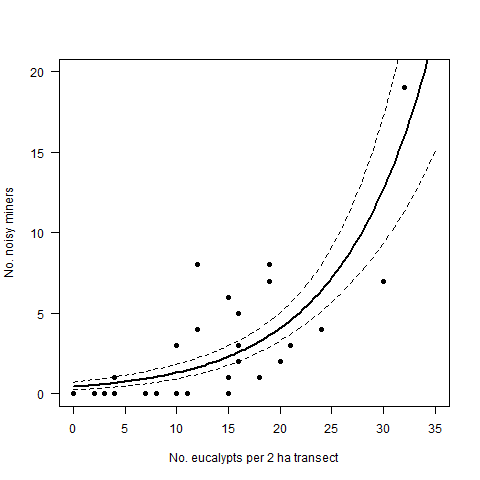

In [21]:
%%R
plot( Minerab~Eucs, data=nminer,
xlim=c(0, 35), ylim=c(0, 20), las=1, pch=19,
xlab="No. eucalypts per 2 ha transect", ylab="No. noisy miners")
lines(exp(newMab$fit) ~ newEucs, lwd=2)
lines(ci_lo ~ newEucs, lty=2)
lines(ci_hi ~ newEucs, lty=2)

In [22]:
%%R
# This confidence interval is not symmetric
cbind(ci_lo[1:10]-exp(newMab$fit)[1:10],ci_hi[1:10]-exp(newMab$fit)[1:10])


         [,1]      [,2]
1  -0.1771621 0.3083789
2  -0.1824626 0.3150945
3  -0.1878884 0.3219061
4  -0.1934408 0.3288129
5  -0.1991208 0.3358140
6  -0.2049293 0.3429084
7  -0.2108673 0.3500950
8  -0.2169355 0.3573726
9  -0.2231345 0.3647399
10 -0.2294651 0.3721956


`GLM.predict(params, exog=None, exposure=None, offset=None, which='mean',linear=None)`

https://www.statsmodels.org/dev/generated/statsmodels.genmod.generalized_linear_model.GLM.predict.html


Statitistic to predict. Default is â€˜meanâ€™.


* â€˜meanâ€™ returns the conditional expectation of endog E(y | x), i.e. inverse of the modelâ€™s link function of linear predictor.

* â€˜linearâ€™ returns the linear predictor of the mean function.

* â€˜var_unscaledâ€™ variance of endog implied by the likelihood model.

In [23]:
# By default, this computes statistics on the linear predictor scale:
out = model_1.predict(exog=pd.DataFrame(data={'Eucs': np.array([10])}))
# Return predictions on mu scale
out1 = model_1.predict(exog=pd.DataFrame(data={'Eucs': np.array([10])}), which="mean")  # default
out2 = model_1.predict(exog=pd.DataFrame(data={'Eucs': np.array([10])}), which="linear")
out3 = model_1.predict(exog=pd.DataFrame(data={'Eucs': np.array([10])}), which="var_unscaled")


print(out1, out2, np.exp(out2), out3)


0    1.30161
dtype: float64 0    0.263602
dtype: float64 0    1.30161
dtype: float64 0    1.30161
dtype: float64


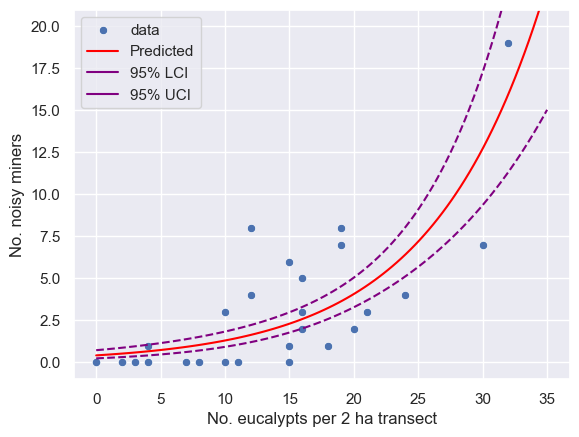

In [24]:
newEucs = np.linspace(0, 35, 100)
#  calculation by hand
newMab = model_1.predict(exog=pd.DataFrame({'Intercept': np.ones((100,)),'Eucs': newEucs}), which="linear").to_numpy()
se_fit = []
for i in np.vstack([np.ones((100,)), newEucs]).T:
    se_fit.append(np.sqrt(i @ model_1.cov_params().to_numpy() @ i.T))
se_fit = np.array(se_fit)

zstar = scipy.stats.norm.ppf(0.975) # For 95% CI
ci_lo = np.exp(newMab-zstar*se_fit)
ci_hi = np.exp(newMab+zstar*se_fit)

fig, ax = plt.subplots()

sns.scatterplot(x='Eucs', y='Minerab', data=nminer, ax=ax ,markers=['o'],label='data')
sns.lineplot(x='x', y='y', data=pd.DataFrame(data={'x':newEucs,'y': np.exp(newMab)}), ax=ax, color='red', label='Predicted')
sns.lineplot(x='x', y='y', data=pd.DataFrame(data={'x':newEucs,'y': ci_lo}), ax=ax, color='purple', markers=['-*'],label='95% LCI')
sns.lineplot(x='x', y='y', data=pd.DataFrame(data={'x':newEucs,'y': ci_hi}), ax=ax, color='purple', markers=['-*'], label='95% UCI')
ax.set_ylim(-1, 21)

ax.lines[1].set_linestyle("--")
ax.lines[2].set_linestyle("--")
ax.set_xlabel('No. eucalypts per 2 ha transect')
ax.set_ylabel('No. noisy miners')
plt.show()


In [25]:
# This confidence interval is not symmetric

print(np.vstack([ci_lo[:10]-np.exp(newMab)[:10], ci_hi[:10]-np.exp(newMab)[:10]]).T)

[[-0.17716891  0.30839945]
 [-0.18246963  0.31511545]
 [-0.18789574  0.32192751]
 [-0.19344838  0.3288348 ]
 [-0.19912863  0.33583639]
 [-0.20493746  0.34293127]
 [-0.21087573  0.35011834]
 [-0.21694424  0.35739641]
 [-0.22314364  0.36476423]
 [-0.22947452  0.37222049]]


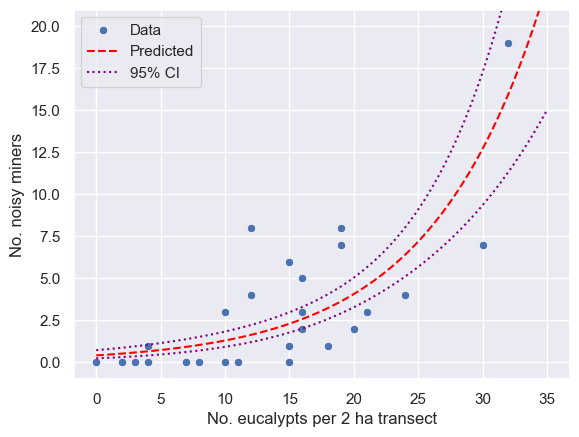

In [26]:
# New predictor data
newEucs = np.linspace(0, 35, 100)
new_data = pd.DataFrame({'Eucs': newEucs})

# Predict using GLM (Poisson-log by default)
predictions = model_1.get_prediction(new_data)
pred_summary = predictions.summary_frame(alpha=0.05)

# Predictions already on the original (response) scale:
fitted_vals = pred_summary['mean']
ci_lower = pred_summary['mean_ci_lower']
ci_upper = pred_summary['mean_ci_upper']

# Plot results
fig, ax = plt.subplots()

sns.scatterplot(x='Eucs', y='Minerab', data=nminer, ax=ax, markers=['o'], label='Data')
ax.plot(newEucs, fitted_vals, color='red', linestyle='--', label='Predicted')
ax.plot(newEucs, ci_lower, color='purple', linestyle=':', label='95% CI')
ax.plot(newEucs, ci_upper, color='purple', linestyle=':')

ax.set_ylim(-1, 21)
ax.set_xlabel('No. eucalypts per 2 ha transect')
ax.set_ylabel('No. noisy miners')
ax.legend()
plt.show()


In [27]:
newEucs = np.linspace(0, 35, 100)
new_data = pd.DataFrame({
    'Intercept': 1.0,
    'Eucs': newEucs
})

#  predict linear predictor scale
pred_linear = model_1.get_prediction(new_data, linear=True, transform=False).summary_frame()
linear_mean = pred_linear['mean']
linear_ci_lower = pred_linear['mean_ci_lower']
linear_ci_upper = pred_linear['mean_ci_upper']

# Response scale (default)
pred_response = model_1.get_prediction(new_data).summary_frame()
response_mean = pred_response['mean']
response_ci_lower = pred_response['mean_ci_lower']
response_ci_upper = pred_response['mean_ci_upper']

# Manual exponential transformation
manual_exp_mean = np.exp(linear_mean)
manual_exp_ci_lower = np.exp(linear_ci_lower)
manual_exp_ci_upper = np.exp(linear_ci_upper)

# Combined dataframe
comparison_df = pd.DataFrame({
    'Eucs': newEucs,
    'Linear_Mean': linear_mean,
    'Linear_CI_Lower': linear_ci_lower,
    'Linear_CI_Upper': linear_ci_upper,
    'Exp_Manual_Mean': manual_exp_mean,
    'Exp_Manual_CI_Lower': manual_exp_ci_lower,
    'Exp_Manual_CI_Upper': manual_exp_ci_upper,
    'Response_Mean': response_mean,
    'Response_CI_Lower': response_ci_lower,
    'Response_CI_Upper': response_ci_upper,
})

# Check - is it wrong?
comparison_df.head(10)


,Eucs,Linear_Mean,Linear_CI_Lower,Linear_CI_Upper,Exp_Manual_Mean,Exp_Manual_CI_Lower,Exp_Manual_CI_Upper,Response_Mean,Response_CI_Lower,Response_CI_Upper
0,0.000000,0.416357,0.239188,0.724757,1.516428,1.270218,2.064229,0.416357,0.239188,0.724757
1,0.353535,0.433478,0.251008,0.748593,1.542613,1.285320,2.114024,0.433478,0.251008,0.748593
2,0.707071,0.451302,0.263406,0.773230,1.570355,1.301355,2.166753,0.451302,0.263406,0.773230
3,1.060606,0.469859,0.276411,0.798694,1.599769,1.318389,2.222636,0.469859,0.276411,0.798694
4,1.414141,0.489180,0.290051,0.825016,1.630978,1.336496,2.281917,0.489180,0.290051,0.825016
5,1.767677,0.509294,0.304357,0.852226,1.664116,1.355753,2.344860,0.509294,0.304357,0.852226
6,2.121212,0.530236,0.319360,0.880354,1.699334,1.376247,2.411754,0.530236,0.319360,0.880354
7,2.474747,0.552039,0.335095,0.909436,1.736791,1.398073,2.482921,0.552039,0.335095,0.909436
8,2.828283,0.574739,0.351595,0.939503,1.776666,1.421333,2.558709,0.574739,0.351595,0.939503
9,3.181818,0.598371,0.368897,0.970592,1.819154,1.446139,2.639507,0.598371,0.368897,0.970592


In [28]:
newEucs = np.linspace(0, 35, 100)
new_data = pd.DataFrame({
    'Intercept': 1.0,
    'Eucs': newEucs
})

# Linear predictions explicitly using your original method
linear_pred = model_1.predict(exog=new_data, which="linear")
se_fit = np.array([
    np.sqrt(row @ model_1.cov_params().to_numpy() @ row.T)
    for row in new_data.values
])

zstar = scipy.stats.norm.ppf(0.975)  # 95% CI

# Manual CI calculation on linear predictor scale
linear_ci_lower = linear_pred - zstar * se_fit
linear_ci_upper = linear_pred + zstar * se_fit

# Manually exponentiate linear predictions
exp_manual_mean = np.exp(linear_pred)
exp_manual_ci_lower = np.exp(linear_ci_lower)
exp_manual_ci_upper = np.exp(linear_ci_upper)

# Response-scale predictions (default)
pred_response = model_1.get_prediction(new_data).summary_frame()
response_mean = pred_response['mean']
response_ci_lower = pred_response['mean_ci_lower']
response_ci_upper = pred_response['mean_ci_upper']

# Combined DataFrame for clear comparison
comparison_df = pd.DataFrame({
    'Eucs': newEucs,

    # Explicit linear scale predictions
    'Linear_Mean': linear_pred,
    'Linear_CI_Lower': linear_ci_lower,
    'Linear_CI_Upper': linear_ci_upper,

    # Explicit manual exponentiation of linear predictions
    'Exp_Manual_Mean': exp_manual_mean,
    'Exp_Manual_CI_Lower': exp_manual_ci_lower,
    'Exp_Manual_CI_Upper': exp_manual_ci_upper,

    # Direct response predictions from the model
    'Response_Mean': response_mean,
    'Response_CI_Lower': response_ci_lower,
    'Response_CI_Upper': response_ci_upper,
})

comparison_df.head(10)


,Eucs,Linear_Mean,Linear_CI_Lower,Linear_CI_Upper,Exp_Manual_Mean,Exp_Manual_CI_Lower,Exp_Manual_CI_Upper,Response_Mean,Response_CI_Lower,Response_CI_Upper
0,0.000000,-0.876211,-1.430504,-0.321919,0.416357,0.239188,0.724757,0.416357,0.239188,0.724757
1,0.353535,-0.835915,-1.382270,-0.289560,0.433478,0.251008,0.748593,0.433478,0.251008,0.748593
2,0.707071,-0.795619,-1.334058,-0.257179,0.451302,0.263406,0.773230,0.451302,0.263406,0.773230
3,1.060606,-0.755322,-1.285867,-0.224777,0.469859,0.276411,0.798694,0.469859,0.276411,0.798694
4,1.414141,-0.715026,-1.237699,-0.192353,0.489180,0.290051,0.825016,0.489180,0.290051,0.825016
5,1.767677,-0.674729,-1.189554,-0.159904,0.509294,0.304357,0.852226,0.509294,0.304357,0.852226
6,2.121212,-0.634433,-1.141435,-0.127431,0.530236,0.319360,0.880354,0.530236,0.319360,0.880354
7,2.474747,-0.594136,-1.093342,-0.094931,0.552039,0.335095,0.909436,0.552039,0.335095,0.909436
8,2.828283,-0.553840,-1.045275,-0.062404,0.574739,0.351595,0.939503,0.574739,0.351595,0.939503
9,3.181818,-0.513544,-0.997238,-0.029849,0.598371,0.368897,0.970592,0.598371,0.368897,0.970592


---
## Recap: The Three Tests (from Exercise 03)

The theory for these tests was covered in Exercise 03. Here is a brief reminder:

| Test | Statistic | Requires fitting | $\phi$ known | $\phi$ unknown |
|------|-----------|-----------------|:---:|:---:|
| **Wald** | $W = (\hat\beta - \beta_0)^T I(\hat\beta)(\hat\beta - \beta_0)$ | Full model | $\chi^2(q)$ | $F(q, n-p)$ |
| **LRT** | $T = (D_0 - D)/\phi$ | Both models | $\chi^2(q)$ | $F(q, n-p)$ |
| **Score** | $R = U^T(\hat\beta_0) I^{-1}(\hat\beta_0) U(\hat\beta_0)$ | Reduced model | $\chi^2(q)$ | $F(q, n-p)$ |

In this exercise, we apply these tests to **real data** and also cover the case when **$\phi$ is unknown** (F-test).


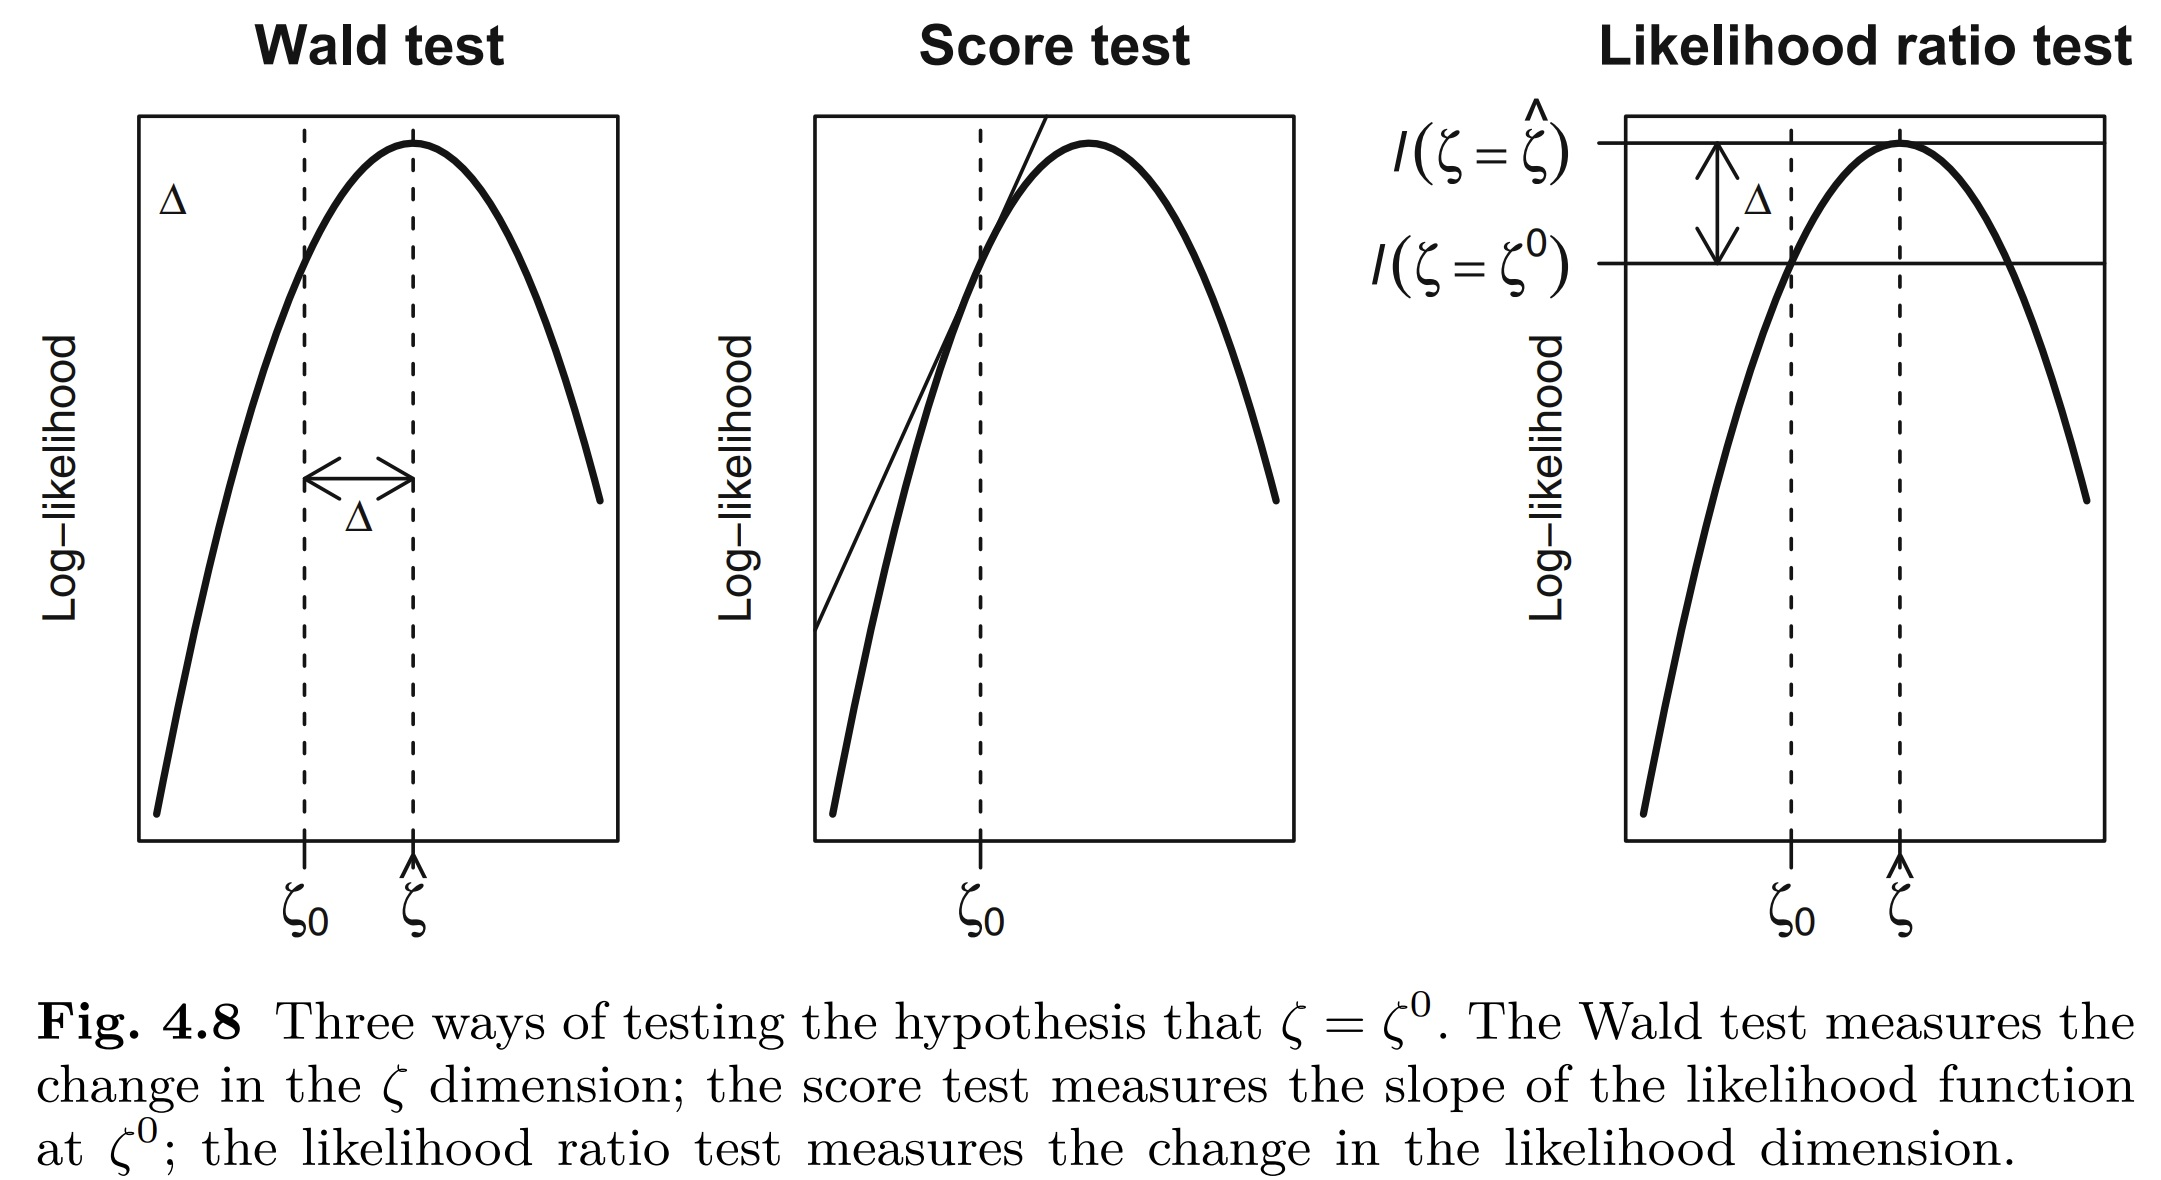

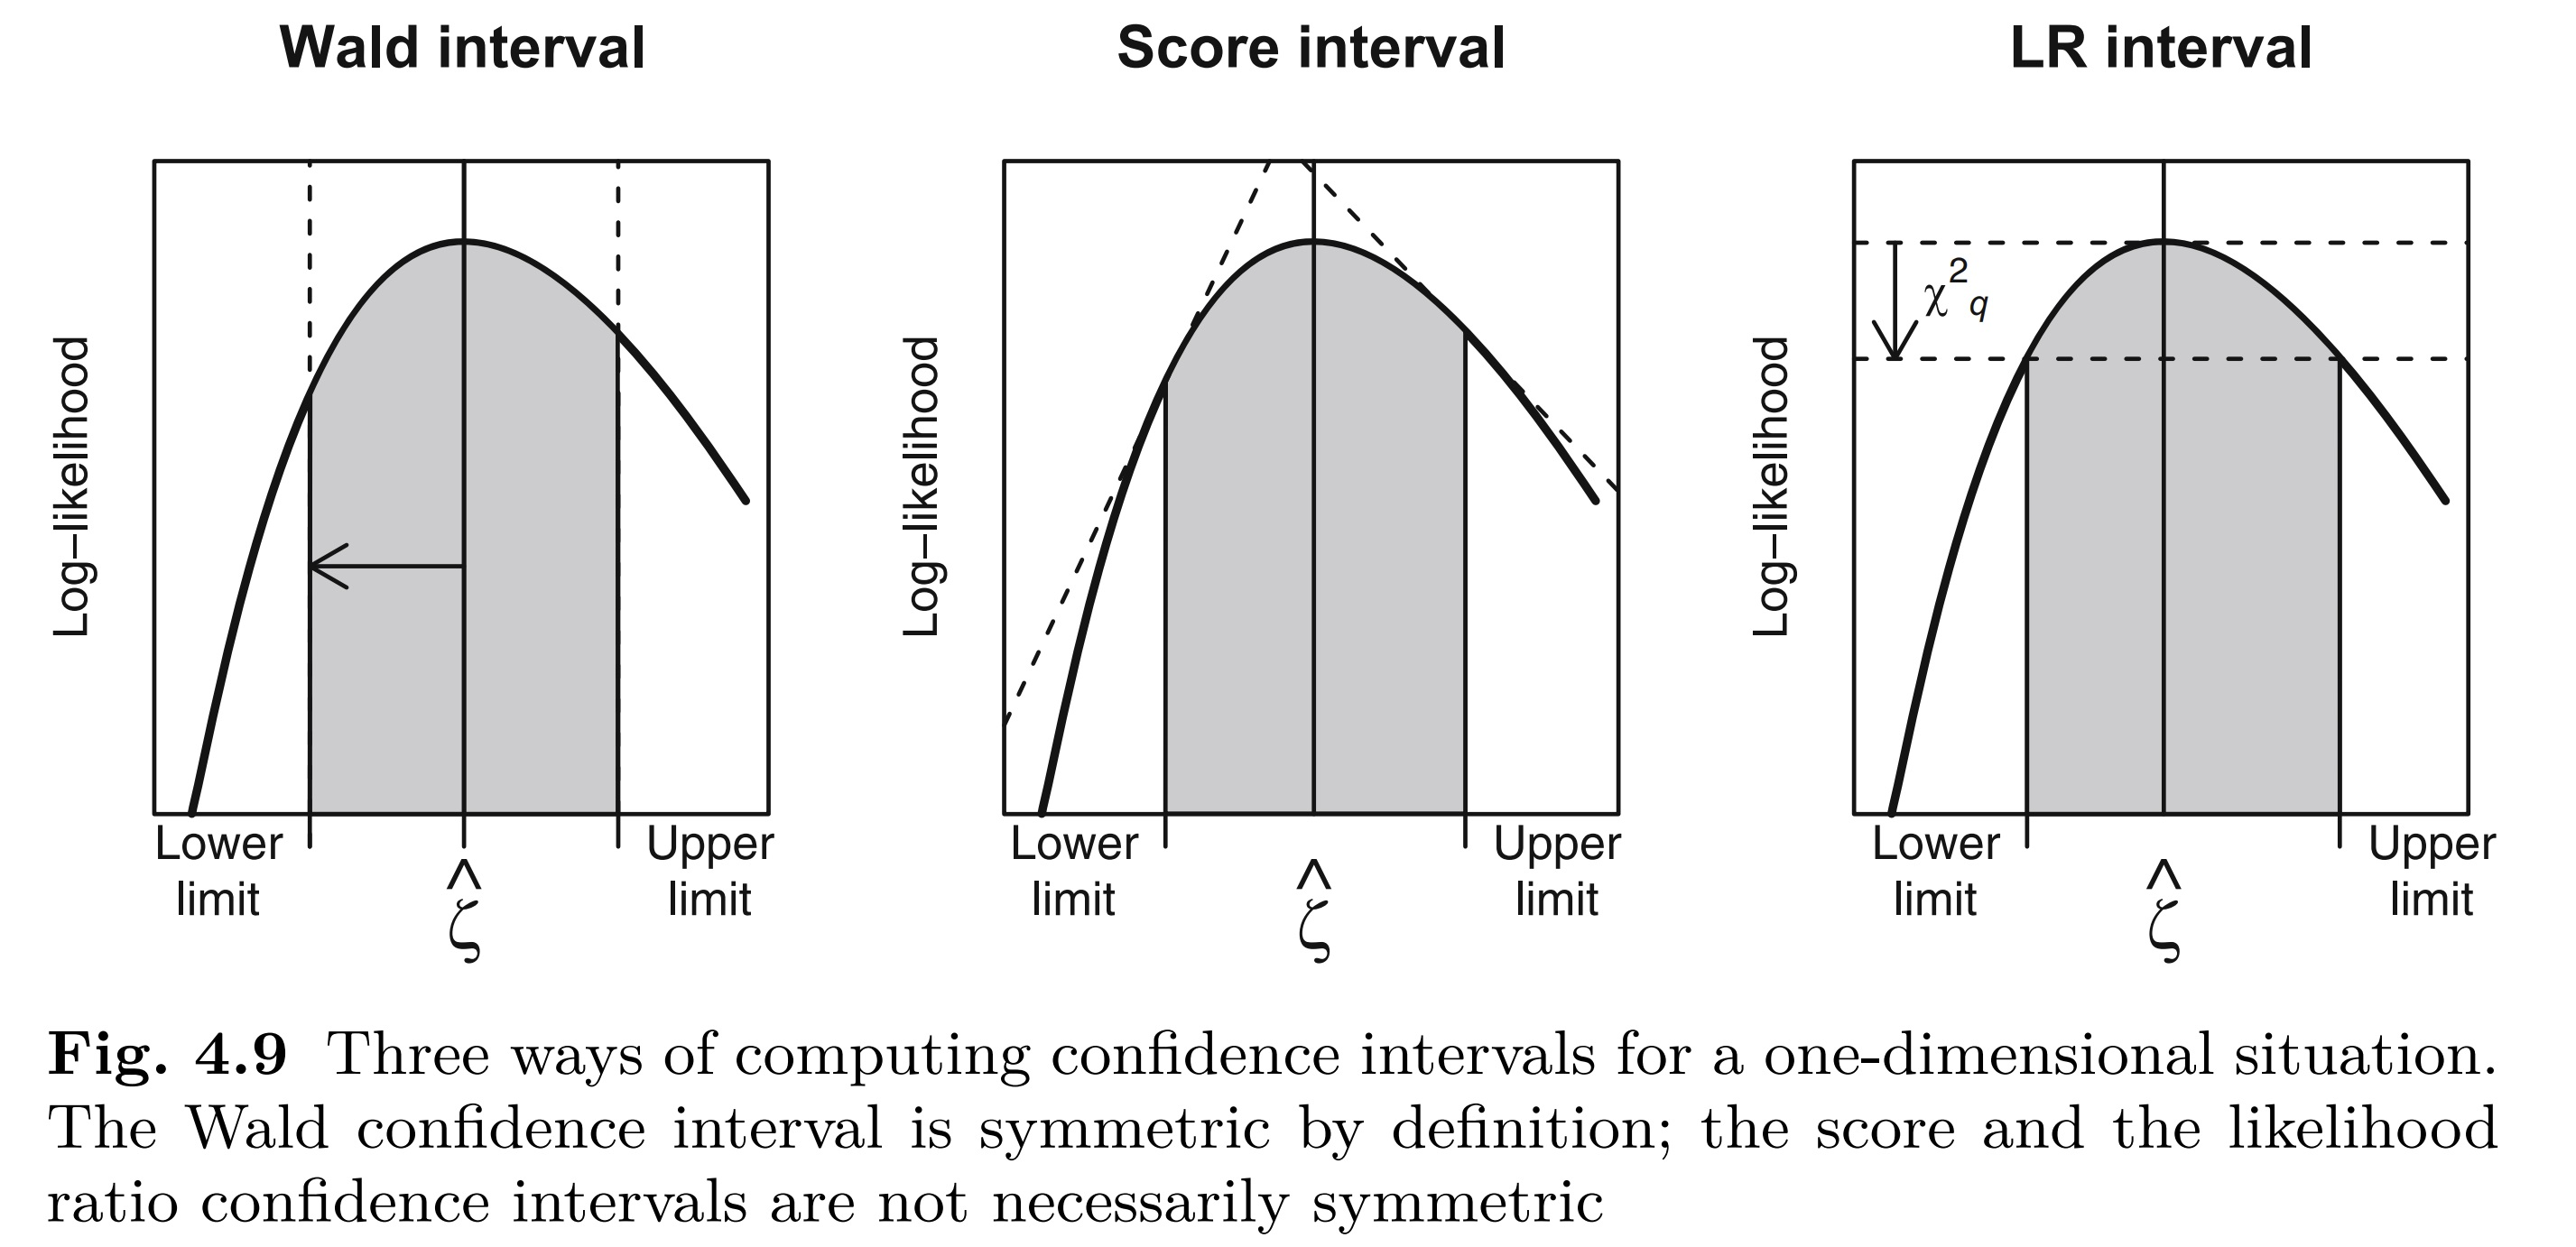

### Comparison of Confidence Intervals:


| Criterion | Wald Interval | Score (Rao) Interval | Likelihood Ratio Interval |
|-----------|---------------|----------------------|---------------------------|
| Symmetry  | Yes (symmetric around $\hat{\beta}$) | Not necessarily symmetric | Not necessarily symmetric |
| Basis of measurement | Distance (horizontal distance between $\hat{\beta}$ and $\beta^0$) | Slope (gradient) of likelihood function at $\beta^0$ | Change in likelihood dimension (vertical change in log-likelihood) |
| Accuracy | Good approximation near MLE; less accurate farther from MLE | More robust and often preferred over Wald interval | Generally most accurate, especially for smaller samples |

---


For Poisson model:
$$D = 2 \sum_{i=1}^n ( y_i log( \frac{y_i}{\hat{\mu_i}}) - ({y_i} - \hat{\mu_i}))$$

In R:

In [29]:
%%R
mu_est_1 <- model_1$fitted.values
Y = nminer$Minerab
sum(Y -mu_est_1)
Y0 <- Y[Y>0]
mu0_est_1 <- mu_est_1[Y>0]
Dev_1 <- 2*sum(Y0*log(Y0/mu0_est_1))
Dev_2 <- 2*sum(Y0*log(Y0/mu0_est_1)) - 2*sum(Y -mu_est_1)
print(Dev_2)


[1] 63.31798


`deviance(fit)`
Returns the residual deviance $D(y,\hat{\mu})$ for the fitted GLM.

In [30]:
%%R
deviance(model_1)

[1] 63.31798


In Python:

In [31]:
mu_est_1 = model_1.predict()
Y = nminer['Minerab'].to_numpy()
np.sum(Y -mu_est_1)
Y0 = Y[Y>0]
mu0_est_1 = mu_est_1[Y>0]
Dev_1 = 2*np.sum(Y0*np.log(Y0/mu0_est_1))
Dev_2 = 2*np.sum(Y0*np.log(Y0/mu0_est_1)) - 2*np.sum(Y -mu_est_1)
print(Dev_2)


63.31797772635137


---
## 2. Comparing Nested Models ($\phi$ is known)

For Poisson GLMs, $\phi = 1$. The LRT statistic is simply the deviance difference:
$$T_1 = D_0 - D \dot{\sim} \chi^2(p - p_0) \quad \text{under } H_0$$


### LRT Test

In [32]:
%%R
model_0 <- glm( Minerab ~ 1,    data=nminer, family=poisson)
model_1 <- glm( Minerab ~ Eucs, data=nminer, family=poisson)

In [33]:
m1 = smf.glm(formula='Minerab~Eucs', data=nminer, family=sm.families.Poisson()) # default log link: family=sm.families.Poisson(link=sm.families.links.log())
model_1 = m1.fit()
m0 = smf.glm(formula='Minerab~1', data=nminer, family=sm.families.Poisson()) # default log link: family=sm.families.Poisson(link=sm.families.links.log())
model_0 = m0.fit()

In [34]:
%%R
print(cbind( "Dev(m0)"= deviance(model_0), "Dev(m1)" = deviance(model_1) ))
print(cbind( "df(m0)" = df.residual(model_0), "df(m1)" = df.residual(model_1)))
L <- deviance(model_0) - deviance(model_1)
L
pchisq(L, df.residual(model_0) - df.residual(model_1), lower.tail=FALSE )


      Dev(m0)  Dev(m1)
[1,] 150.5453 63.31798
     df(m0) df(m1)
[1,]     30     29
[1] 9.673697e-21


In [35]:
%%R
anova(model_0,model_1,test="LRT")

Analysis of Deviance Table

Model 1: Minerab ~ 1
Model 2: Minerab ~ Eucs
  Resid. Df Resid. Dev Df Deviance  Pr(>Chi)    
1        30    150.545                          
2        29     63.318  1   87.227 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [36]:
%%R
anova(model_1, test="Chisq")

Analysis of Deviance Table

Model: poisson, link: log

Response: Minerab

Terms added sequentially (first to last)


     Df Deviance Resid. Df Resid. Dev  Pr(>Chi)    
NULL                    30    150.545              
Eucs  1   87.227        29     63.318 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [37]:
from scipy.stats import chi2

# Compute deviance difference explicitly
L = model_0.deviance - model_1.deviance
df_diff = model_0.df_resid - model_1.df_resid
p_value = chi2.sf(L, df_diff)

print(f'LRT Statistic: {L:.4f}, df: {df_diff}, p-value: {p_value:.4f}')


LRT Statistic: 87.2273, df: 1, p-value: 0.0000


**Note:** While `statsmodels` does not have a built-in `anova()` for comparing two GLMs like R does, the custom `Anova` helper class (from `helpers.py`) provides this functionality. See usage below.

The P-value is very small, indicating that the addition of Eucs is significant.

### Score test

In [38]:
 %%R
# Add one variable
library(statmod) # Provides glm.scoretest
#? glm.scoretest

model_0 <- glm( Minerab ~ 1,    data=nminer, family=poisson)
model_1 <- glm( Minerab ~ Eucs, data=nminer, family=poisson)
z_stat <- glm.scoretest(model_1, nminer$Eucs)
p_val <- 2 * pnorm( abs(z_stat), lower.tail=FALSE)
p_val

IndentationError: unexpected indent (1282429572.py, line 1)

In [ ]:
%%R
# Compare model with saturated model
Y <- nminer$Minerab
X <- nminer$Eucs
mu_est_1 <- model_1$fitted.values

Rao <- sum((Y-mu_est_1)^2/mu_est_1)
Rao
# p-value  - from Rao statistics
# H0: model fit data
prao <- pchisq(Rao, model_1$df.residual, ncp=0, lower.tail = FALSE);
prao

In [ ]:
%%R
I <- diag(1,length(Y),length(Y))
model_f <- glm(formula=Y~X,family=poisson(link = "log"))
model_s <- glm(formula=Y~I,family=poisson(link = "log"))
anova(model_f,model_s, test = "Rao")
#anova(model_1,model_0, test = "Rao")


The evidence strongly suggests that Eucs should be added to the model.

In [ ]:
print(model_0.summary())
print(model_1.summary())

In [ ]:
anova = Anova()

anova(model_0, model_1, test='chisq')

In [ ]:
anova(model_0,model_1,test="LRT")

### Score test

In [ ]:
# Compare model with saturated model
Y = nminer['Minerab']
X = nminer['Eucs']
mu_est_1 = model_1.predict()

Rao = np.sum((Y-mu_est_1)**2/mu_est_1)
print(Rao)
# p-hodnota testu adekvatnosti modelu (pomoci Raovy statistiky)
# H0: model dobre popisuje data
prao = scipy.stats.chi2.sf(Rao, df=model_1.df_resid)
print(prao)

In [ ]:
I = np.diag(np.ones((len(Y),)))

model_s = sm.GLM(endog=Y.to_numpy(), exog=I, family=sm.families.Poisson()).fit()
model_f = smf.glm(formula='Minerab~Eucs', data=nminer, family=sm.families.Poisson()).fit()

display(anova(model_f, model_s, test='rao'))
anova(model_1, model_0, test='rao')


The evidence strongly suggests that Eucs should be added to the model.

---
## 3. Estimating $\phi$

For distributions where $\phi$ is unknown (Normal, Gamma, Inverse Gaussian), we need to estimate it.

Three approaches:
* The Maximum Likelihood Estimator of $\phi$
* Pearson Estimator: $\hat{\phi}_P = \frac{1}{n-p} \sum_{i=1}^{n} \frac{(y_i - \hat{\mu}_i)^2}{V(\hat{\mu}_i)}$
* Mean Deviance Estimator: $\hat{\phi}_D = \frac{D(y,\hat{\mu})}{n-p}$


### Pearson Estimator of $\phi$

$$\phi = \frac{var[Y_i]}{a_i b''(\theta_i)} \Rightarrow \hat{\phi} = \frac{1}{n-p} \sum_{i=1}^{n} \frac{(y_i - \hat{\mu_i})^2}{a_i b''(\theta(\hat{\mu_i}))}$$

### Mean Deviance Estimator of $\phi$

$$\hat{\phi} = \frac{D(y,\hat{\mu})}{n-p}$$



For Binomial and Poisson glms, $\phi = 1$ and no estimation is necessary. However, the issue may arise for over-dispersed binomial or Poisson GLMs,
which are considered in later exercises.

Use data `trees` and compute Pearson and Deviance estimator of $\phi$

In [ ]:
%%R -o trees
data(trees)
ggpairs(trees)

In [ ]:
g = sns.PairGrid(trees)
g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)
g.map_upper(sns.histplot)

plt.show()

In [ ]:
%%R
model_trees_1 <- glm( Volume ~ log(Height) +  log(Girth), data=trees, family=Gamma(link="log"))
summary(model_trees_1)

In [ ]:
mod_t_1 = smf.glm(formula = 'Volume ~ np.log(Height) + np.log(Girth)', data=trees,
                        family=sm.families.Gamma(sm.families.links.Log()))
model_trees_1 = mod_t_1.fit(scale='X2')

print(model_trees_1.summary())

In [ ]:
#Compute the Pearson estimator of $\phi$
model_trees_1.resid_pearson.T @ model_trees_1.resid_pearson.T / model_trees_1.df_resid

In [ ]:
phi_meandev = model_trees_1.deviance / model_trees_1.df_resid
phi_pearson = model_trees_1.scale

print(f'Meand dev: {phi_meandev}; Pearson estimate: {phi_pearson}')

In [ ]:
print(mod_t_1.fit(scale='dev').summary())
print(mod_t_1.fit(scale='X2').summary())

**Important:** R (and `statsmodels` by default) reports Z-tests in the summary, treating the dispersion as known. For families where $\phi$ is unknown (Gamma, Normal), the correct tests should use the $t$-distribution with $n-p$ degrees of freedom. In R, this is handled automatically by the `summary.glm()` function. In `statsmodels`, use the `scale` parameter when fitting (e.g., `scale='X2'` for Pearson estimate).

In [ ]:
model_trees_0 = smf.glm(formula='Volume~1', data=trees,
                        family=sm.families.Gamma(sm.families.links.Log())).fit()


# unfortunately statsmodels.glms have no `update functionality` as far as I know
# but we can perform simple string operation to update formula instead
model_trees_G = smf.glm(formula=model_trees_0.model.formula + '+ np.log(Girth)',
                        data=trees,
                        family=sm.families.Gamma(sm.families.links.Log())).fit()

model_trees_GH = smf.glm(formula=model_trees_G.model.formula + '+ np.log(Height)',
                        data=trees,
                        family=sm.families.Gamma(sm.families.links.Log())).fit()

print(f'Deviances are: {model_trees_0.deviance}, {model_trees_G.deviance}, {model_trees_GH.deviance}')
print(f'Residual dfs are: {model_trees_0.df_resid}, {model_trees_G.df_resid}, {model_trees_GH.df_resid}')
dev1 = model_trees_0.deviance-model_trees_G.deviance
dev2 = model_trees_G.deviance-model_trees_GH.deviance
df1 = model_trees_0.df_resid-model_trees_G.df_resid
df2 = model_trees_G.df_resid-model_trees_GH.df_resid


In [ ]:
F_Pearson = ( dev1/df1, dev2/df2 ) / phi_pearson
F_meandev = ( dev1/df1, dev2/df2 ) / phi_meandev

P_Pearson = [scipy.stats.f.sf( i, df1, model_trees_GH.df_resid ) for i in F_Pearson]
P_meandev = [scipy.stats.f.sf( i, df2, model_trees_GH.df_resid) for i in F_meandev]
tab = pd.DataFrame(data={'F_pearson': F_Pearson, 'P_pearson': P_Pearson,
                         'F_meandev': F_meandev, 'P_meandev': P_meandev}, index=pd.Index(["Girth","Height"]))
tab

In [ ]:
display(anova(model_trees_GH, test="F", dispersion=phi_meandev))
anova(model_trees_GH, test="F", dispersion=phi_pearson)

In [ ]:
anova(model_trees_0, model_trees_GH, test="F")

In [ ]:
anova(model_trees_G, model_trees_GH, test="F")

Questions:
* What if I swap the order of independet varialbes in the definition `Volume ~ Girth + Height`?


---
## 4. Comparing Non-nested Models: AIC and BIC

For non-nested models, we cannot use LRT or Wald tests. Instead we use information criteria:

$$\text{AIC} = -2 \ell(\hat{\mu}, \phi; y) + 2p, \qquad \text{BIC} = -2 \ell(\hat{\mu}, \phi; y) + (\log n) \cdot p$$

- Smaller values indicate better models
- BIC penalizes model complexity more than AIC
- Neither is a formal hypothesis test (no p-value)


In [ ]:
%%R
model_trees_1 <- glm( Volume ~ log(Height) +  log(Girth), data=trees, family=Gamma(link="log"))
summary(model_trees_1)

In [ ]:
#%%R
# ? weights.glm

Working residuals: $e_i =(y_i - \hat{mu}_i) \cdot g'(\hat{\mu}_i)$

Working weight:  from the final iteration of the IRLS algorithm used internally by GLMs, representing inverse variance components, evaluated at the fitted values from the last iteration.

In [ ]:
%%R
#Compute the Pearson estimator of $\phi$
w <- weights(model_trees_1, type="working") # working return results from the last iteration
e <- residuals(model_trees_1, type="working")
sum(w*e^2) / df.residual(model_trees_1)

In [ ]:
%%R
phi_meandev <- deviance(model_trees_1) / df.residual(model_trees_1)
phi_pearson <- summary(model_trees_1)$dispersion
cbind(Mean_deviance=phi_meandev, Pearson=phi_pearson)


In [ ]:
%%R
coef(summary(model_trees_1, dispersion=phi_meandev))
coef(summary(model_trees_1))

In [ ]:
%%R
model_trees_0 <- glm( Volume ~ 1, family=Gamma(link="log"), data=trees)
model_trees_G <- update(model_trees_0,.~.+ log(Girth) )
model_trees_GH <- update(model_trees_G,.~.+ log(Height) )
cbind( deviance(model_trees_0), deviance(model_trees_G), deviance(model_trees_GH))
cbind( df.residual(model_trees_0), df.residual(model_trees_G), df.residual(model_trees_GH))

dev1 <- deviance(model_trees_0) - deviance(model_trees_G);dev1
dev2 <- deviance(model_trees_G) - deviance(model_trees_GH);dev2
df1 <- df.residual(model_trees_0) - df.residual(model_trees_G)
df2 <- df.residual(model_trees_G) - df.residual(model_trees_GH)


In [ ]:
%%R
F_Pearson <- c( dev1/df1, dev2/df2 ) / phi_pearson
F_meandev <- c( dev1/df1, dev2/df2 ) / phi_meandev
P_Pearson <- pf( F_Pearson, df1, df.residual(model_trees_GH), lower.tail=FALSE )
P_meandev <- pf( F_meandev, df2, df.residual(model_trees_GH), lower.tail=FALSE )
tab <- data.frame(F_Pearson, P_Pearson, F_meandev, P_meandev)
rownames(tab) <- c("Girth","Height")
print(tab, digits=3)

In [ ]:
%%R
anova(model_trees_GH, test="F", dispersion=phi_meandev)
anova(model_trees_GH, test="F", dispersion=phi_pearson)

Assume we want to compare the models:
$$Model \ 1: \ \text{log} \mu = \beta_0 +  2 x_1 + \beta_2 x_2$$
$$Model \ 2: \ \text{log} \mu = \beta_0 + \beta_1 x_1 + \ x_2$$


In [ ]:
Model_1 = smf.glm(formula='Volume~np.log(Height)', data=trees, offset=2*np.log(trees['Girth']),
                        family=sm.families.Gamma(sm.families.links.Log())).fit()

Model_2 = smf.glm(formula='Volume~np.log(Girth)', data=trees, offset=np.log(trees['Height']),
                        family=sm.families.Gamma(sm.families.links.Log())).fit()

print('AIC:', Model_1.aic, Model_2.aic)
print('BIC:', Model_1.bic_llf, Model_2.bic_llf)



In [ ]:
print(Model_1.summary())

In [ ]:
p = 2 + 1
n = len(trees['Volume'])
phi_hat = Model_1.scale

AIC  = -2*Model_1.llf + 2*p;
print(AIC)
BIC  = -2*Model_1.llf + p*np.log(n);
print(BIC)
# Model_1.summary()
AIC_dev = Model_1.deviance/phi_hat + 2*p
print(AIC_dev)

In [ ]:
print(Model_1.summary())

In [ ]:
%%R
Model_1 <- glm( Volume ~ offset(2*log(Girth)) + log(Height), family=Gamma(link="log"), data=trees)
Model_2 <- glm( Volume ~ log(Girth) + offset(log(Height)), family=Gamma(link="log"), data=trees)
cbind(AIC(Model_1), AIC(Model_2))
cbind(BIC(Model_1), BIC(Model_2))


In [ ]:
%%R
summary(Model_1)

In [ ]:
%%R
p <- 2 + 1  # Number of parameters (intercept + 2 predictors)
n <- length(trees$Volume)

# Extract dispersion parameter from the model summary (for GLM)
phi_hat <- summary(Model_1)$dispersion

# Compute log-likelihood correctly
log_lik <- as.numeric(logLik(Model_1))

# Compute AIC and BIC directly using log-likelihood
AIC <- -2 * log_lik + 2 * p
BIC <- -2 * log_lik + log(n) * p

# Alternatively, using deviance explicitly:
AIC_deviance <- deviance(Model_1) / phi_hat + 2 * p

# Results
print(AIC)
print(BIC)
AIC_deviance


In [ ]:
%%R
summary(Model_1)

---
## 5. Automated Model Selection

Stepwise selection uses AIC to iteratively add or remove variables:
- **Forward:** start with null model, add the variable that decreases AIC the most
- **Backward:** start with full model, remove the variable whose removal decreases AIC the most
- **Both:** combine forward and backward steps


In [ ]:
%%R
model_0 <- glm( Volume~1, data=trees, family=Gamma(link="log"))
model_1 <- glm( Volume~log(Girth) + log(Height),data=trees, family=Gamma(link="log"))
model_b1 <- step(model_0, scope=list(lower=model_0, upper=model_1), direction="backward")
model_b2 <- step(model_1, scope=list(lower=model_0, upper=model_1), direction="backward")
model_b3 <- step(model_0, scope=list(lower=model_0, upper=model_1), direction="both")
model_b3


# Next week: Exercise 05

## GLM Diagnostics and Analysis of residuals





## Your turn: Home work:

Problem 7.5. from: Peter K. Dunn Â· Gordon K. Smyth
Generalized Linear Models With Examples in R
https://link.springer.com/content/pdf/10.1007/978-1-4419-0118-7.pdf

Nambe Mills, Santa Fe, New Mexico, is a tableware manufacturer. After casting, items produced by Nambe Mills are shaped, ground, buffed, and
polished. In 1989, as an aid to rationalizing production of its 100 products, the company recorded the total grinding and polishing times and the diameter of each item (data set: nambeware). In this problem, only consider the item price y and item diameter x. In Problem 6.11, a glm was fitted to these data.

1. Use a Wald test to determine if diameter is significant.
2. Use a score test to determine if diameter is significant.
3. Use a likelihood ratio test to determine if diameter is significant.
4. Compare the results from the Wald, score and likelihood ratio tests. Comment.
5. Is the saddlepoint approximation expected to be accurate? Explain.
6. Is the Central Limit Theorem expected to be accurate? Explain.
7. Find the 95% Wald confidence intervals for the regression coefficients.
8. Plot the price against diameter, and show the relationship described by
the fitted model. Also plot the lines indicating the lower and upper 95%
confidence intervals for these fitted value

In [ ]:
%%R
install.packages("GLMsData")
library(GLMsData)

In [ ]:
%%R -o nambeware
data(nambeware)
nambeware

In [ ]:
nambeware